## Evaulating Model Performance on the 5-min MHAR Feature Set.

## Step 1: Load All MHAR Forecasts

We load the one-day-ahead out-of-sample forecasts for all models estimated on the MHAR 
feature set (RVD, RVW, RVM). Models are organised into four categories following 
Christensen et al. (2023): benchmark HAR-type models, regularized linear models, 
tree-based models, and neural networks. All forecast files share a common date index 
covering the test period 2016-04-21 to 2020-08-06, with 1,099 observations.

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Define base paths ---
base_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR"

paths = {
    "Benchmark":   os.path.join(base_path, "Benchmark Models"),
    "Regularized": os.path.join(base_path, "Regularized Linear Models"),
    "Tree":        os.path.join(base_path, "Tree-based Models"),
    "NN":          os.path.join(base_path, "Neural Networks")
}

# --- Load benchmark models ---
HAR    = pd.read_csv(os.path.join(paths["Benchmark"], "forecasts_HAR.csv"),    index_col=0, parse_dates=True)
LogHAR = pd.read_csv(os.path.join(paths["Benchmark"], "forecasts_LogHAR.csv"), index_col=0, parse_dates=True)
LevHAR = pd.read_csv(os.path.join(paths["Benchmark"], "forecasts_LevHAR.csv"), index_col=0, parse_dates=True)
SHAR   = pd.read_csv(os.path.join(paths["Benchmark"], "forecasts_SHAR.csv"),   index_col=0, parse_dates=True)
HARQ   = pd.read_csv(os.path.join(paths["Benchmark"], "forecasts_HARQ.csv"),   index_col=0, parse_dates=True)

# --- Load regularized linear models ---
RR = pd.read_csv(os.path.join(paths["Regularized"], "forecasts_RR.csv"),  index_col=0, parse_dates=True)
LA = pd.read_csv(os.path.join(paths["Regularized"], "forecasts_LA.csv"),  index_col=0, parse_dates=True)
EN = pd.read_csv(os.path.join(paths["Regularized"], "forecasts_EN.csv"),  index_col=0, parse_dates=True)

# --- Load tree-based models ---
RF = pd.read_csv(os.path.join(paths["Tree"], "forecasts_RF.csv"), index_col=0, parse_dates=True)
GB = pd.read_csv(os.path.join(paths["Tree"], "forecasts_GB.csv"), index_col=0, parse_dates=True)

# --- Load neural network ---
NN1 = pd.read_csv(os.path.join(paths["NN"], "forecasts_NN1.csv"), index_col=0, parse_dates=True)

# --- Verify all files loaded correctly ---
print("Model forecast shapes and date ranges:")
print(f"{'Model':<20} {'Shape':<15} {'Start':<15} {'End'}")
print("-" * 65)
for name, df in [("HAR", HAR), ("LogHAR", LogHAR), ("LevHAR", LevHAR), 
                  ("SHAR", SHAR), ("HARQ", HARQ), ("RR", RR), 
                  ("LA", LA), ("EN", EN), ("RF", RF), ("GB", GB), 
                  ("NN1", NN1)]:
    print(f"{name:<20} {str(df.shape):<15} {str(df.index[0].date()):<15} {str(df.index[-1].date())}")

Model forecast shapes and date ranges:
Model                Shape           Start           End
-----------------------------------------------------------------
HAR                  (1099, 2)       2016-04-21      2020-08-06
LogHAR               (1099, 2)       2016-04-21      2020-08-06
LevHAR               (1099, 2)       2016-04-21      2020-08-06
SHAR                 (1099, 2)       2016-04-21      2020-08-06
HARQ                 (1099, 2)       2016-04-21      2020-08-06
RR                   (1099, 2)       2016-04-21      2020-08-06
LA                   (1099, 2)       2016-04-21      2020-08-06
EN                   (1099, 2)       2016-04-21      2020-08-06
RF                   (1099, 2)       2016-04-21      2020-08-06
GB                   (1099, 2)       2016-04-21      2020-08-06
NN1                  (1099, 3)       2016-04-21      2020-08-06


## Step 2: Construct Unified Forecast Dictionary

We extract the actual and forecast series for each model into a unified dictionary, 
enabling consistent downstream evaluation. For NN1 we create two separate entries 
corresponding to the single best network and the top-5 ensemble average respectively, 
analogous to the NN1_1 and NN1_10 specifications in Christensen et al. (2023).

In [5]:
# Extract actual RV series (common across all models)
y_actual = HAR["RV_actual"].values

# --- Build unified forecast dictionary ---
forecasts = {
    "HAR":          HAR["RV_forecast"].values,
    "LogHAR":       LogHAR["RV_forecast"].values,
    "LevHAR":       LevHAR["RV_forecast"].values,
    "SHAR":         SHAR["RV_forecast"].values,
    "HARQ":         HARQ["RV_forecast"].values,
    "RR":           RR["RV_forecast"].values,
    "LA":           LA["RV_forecast"].values,
    "EN":           EN["RV_forecast"].values,
    "RF":           RF["RV_forecast"].values,
    "GB":           GB["RV_forecast"].values,
    "NN1_best":     NN1["RV_forecast_best"].values,
    "NN1_ensemble": NN1["RV_forecast_ensemble"].values,
}

# --- Verify actual RV is consistent across all files ---
print("Consistency check on RV_actual across all model files:")
all_match = True
for name, df in [("LogHAR", LogHAR), ("LevHAR", LevHAR), ("SHAR", SHAR), 
                  ("HARQ", HARQ), ("RR", RR), ("LA", LA), ("EN", EN), 
                  ("RF", RF), ("GB", GB), ("NN1", NN1)]:
    match = np.allclose(df["RV_actual"].values, y_actual)
    print(f"  {name:<20} RV_actual matches HAR: {match}")
    if not match:
        all_match = False

print(f"\nAll RV_actual series identical: {all_match}")
print(f"Number of models loaded:        {len(forecasts)}")
print(f"Test observations:              {len(y_actual)}")

Consistency check on RV_actual across all model files:
  LogHAR               RV_actual matches HAR: True
  LevHAR               RV_actual matches HAR: True
  SHAR                 RV_actual matches HAR: True
  HARQ                 RV_actual matches HAR: True
  RR                   RV_actual matches HAR: True
  LA                   RV_actual matches HAR: True
  EN                   RV_actual matches HAR: True
  RF                   RV_actual matches HAR: True
  GB                   RV_actual matches HAR: True
  NN1                  RV_actual matches HAR: True

All RV_actual series identical: True
Number of models loaded:        12
Test observations:              1099


## Step 3: Compute Absolute and Relative MSE

Following Christensen et al. (2023), we compute the out-of-sample mean squared error 
for each model and express it relative to the HAR benchmark. A relative MSE below unity 
indicates the model outperforms HAR, while a value above unity indicates underperformance. 
The HAR model serves as the natural benchmark given its status as the dominant model in 
the realized volatility forecasting literature.

In [8]:
# --- Compute MSE for all models ---
mse_results = {}
for name, forecast in forecasts.items():
    errors = y_actual - forecast
    mse_results[name] = np.mean(errors ** 2)

# HAR benchmark MSE
mse_HAR = mse_results["HAR"]

# --- Build results table ---
results_table = pd.DataFrame({
    "MSE":          {name: mse for name, mse in mse_results.items()},
    "Relative_MSE": {name: mse / mse_HAR for name, mse in mse_results.items()},
}).sort_values("Relative_MSE")

print(f"HAR benchmark MSE: {mse_HAR:.6e}")
print(f"\nModel Performance — MHAR Feature Set")
print(f"{'Rank':<6} {'Model':<20} {'MSE':<18} {'Relative MSE':<15}")
print("-" * 60)
for rank, (name, row) in enumerate(results_table.iterrows(), 1):
    marker = " <-- HAR benchmark" if name == "HAR" else ""
    print(f"{rank:<6} {name:<20} {row['MSE']:.6e}   {row['Relative_MSE']:.4f}{marker}")

HAR benchmark MSE: 5.663594e-08

Model Performance — MHAR Feature Set
Rank   Model                MSE                Relative MSE   
------------------------------------------------------------
1      HARQ                 4.792463e-08   0.8462
2      RF                   5.189091e-08   0.9162
3      LevHAR               5.466744e-08   0.9652
4      LogHAR               5.476376e-08   0.9669
5      GB                   5.512296e-08   0.9733
6      RR                   5.628678e-08   0.9938
7      HAR                  5.663594e-08   1.0000 <-- HAR benchmark
8      NN1_ensemble         5.739156e-08   1.0133
9      EN                   5.784154e-08   1.0213
10     NN1_best             5.797020e-08   1.0236
11     SHAR                 5.837974e-08   1.0308
12     LA                   5.885116e-08   1.0391


## Step 4: Diebold-Mariano Tests Against HAR Benchmark

We conduct pairwise Diebold-Mariano (DM) tests for equal predictive accuracy between 
each model and the HAR benchmark, following Diebold and Mariano (1995). The loss 
differential is defined as $d_t = e_{HAR,t}^2 - e_{i,t}^2$, where a positive value 
indicates that model $i$ outperforms HAR on day $t$. The null hypothesis of equal 
predictive accuracy is tested against the one-sided alternative that model $i$ 
outperforms HAR. Newey-West standard errors with 5 lags are used to account for 
potential autocorrelation in the loss differential series.

In [11]:
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

def diebold_mariano_test(actual, forecast_bench, forecast_model, lags=5):
    """
    One-sided DM test: H1 that model outperforms benchmark.
    Returns DM statistic and p-value.
    Positive DM stat indicates model beats benchmark.
    """
    e_bench = actual - forecast_bench
    e_model = actual - forecast_model
    
    # Loss differential: positive means model is better
    d = e_bench**2 - e_model**2
    
    T = len(d)
    d_mean = d.mean()
    
    # Newey-West variance estimate
    d_demeaned = d - d_mean
    gamma_0 = np.mean(d_demeaned**2)
    nw_var = gamma_0
    for lag in range(1, lags + 1):
        gamma_lag = np.mean(d_demeaned[lag:] * d_demeaned[:-lag])
        nw_var += 2 * (1 - lag / (lags + 1)) * gamma_lag
    
    dm_stat = d_mean / np.sqrt(nw_var / T)
    
    # One-sided p-value: H1 that model beats benchmark (positive DM)
    from scipy import stats
    p_value = 1 - stats.norm.cdf(dm_stat)
    
    return dm_stat, p_value

# --- Run DM tests for all models vs HAR ---
dm_results = {}
for name, forecast in forecasts.items():
    if name == "HAR":
        continue
    dm_stat, p_val = diebold_mariano_test(
        actual=y_actual,
        forecast_bench=forecasts["HAR"],
        forecast_model=forecast,
        lags=5
    )
    dm_results[name] = {"DM_stat": dm_stat, "p_value": p_val}

# --- Build full summary table ---
summary_table = results_table.copy()
summary_table["DM_stat"] = np.nan
summary_table["p_value"] = np.nan
summary_table["Significance"] = ""

for name, res in dm_results.items():
    summary_table.loc[name, "DM_stat"] = res["DM_stat"]
    summary_table.loc[name, "p_value"] = res["p_value"]
    p = res["p_value"]
    if p < 0.01:
        summary_table.loc[name, "Significance"] = "***"
    elif p < 0.05:
        summary_table.loc[name, "Significance"] = "**"
    elif p < 0.10:
        summary_table.loc[name, "Significance"] = "*"
    else:
        summary_table.loc[name, "Significance"] = ""

print(f"Diebold-Mariano Tests vs HAR Benchmark — MHAR Feature Set")
print(f"H1: Model outperforms HAR (one-sided)")
print(f"Significance: * p<0.10, ** p<0.05, *** p<0.01")
print()
print(f"{'Model':<20} {'Rel. MSE':<12} {'DM Stat':<12} {'p-value':<12} {'Sig.'}")
print("-" * 65)
for name, row in summary_table.iterrows():
    dm_str  = f"{row['DM_stat']:.4f}"  if not np.isnan(row['DM_stat'])  else "—"
    p_str   = f"{row['p_value']:.4f}"  if not np.isnan(row['p_value'])  else "—"
    print(f"{name:<20} {row['Relative_MSE']:.4f}       {dm_str:<12} {p_str:<12} {row['Significance']}")

Diebold-Mariano Tests vs HAR Benchmark — MHAR Feature Set
H1: Model outperforms HAR (one-sided)
Significance: * p<0.10, ** p<0.05, *** p<0.01

Model                Rel. MSE     DM Stat      p-value      Sig.
-----------------------------------------------------------------
HARQ                 0.8462       1.6132       0.0533       *
RF                   0.9162       1.0269       0.1522       
LevHAR               0.9652       0.7965       0.2129       
LogHAR               0.9669       0.5452       0.2928       
GB                   0.9733       0.4668       0.3203       
RR                   0.9938       0.8175       0.2068       
HAR                  1.0000       —            —            
NN1_ensemble         1.0133       -0.1565      0.5622       
EN                   1.0213       -1.2759      0.8990       
NN1_best             1.0236       -0.3064      0.6204       
SHAR                 1.0308       -0.9352      0.8252       
LA                   1.0391       -2.1092      0.9825 

/var/folders/ym/wl40dz313jq5xxzrl0tc87w00000gn/T/ipykernel_26240/2118415980.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")   # blue = better, red = worse


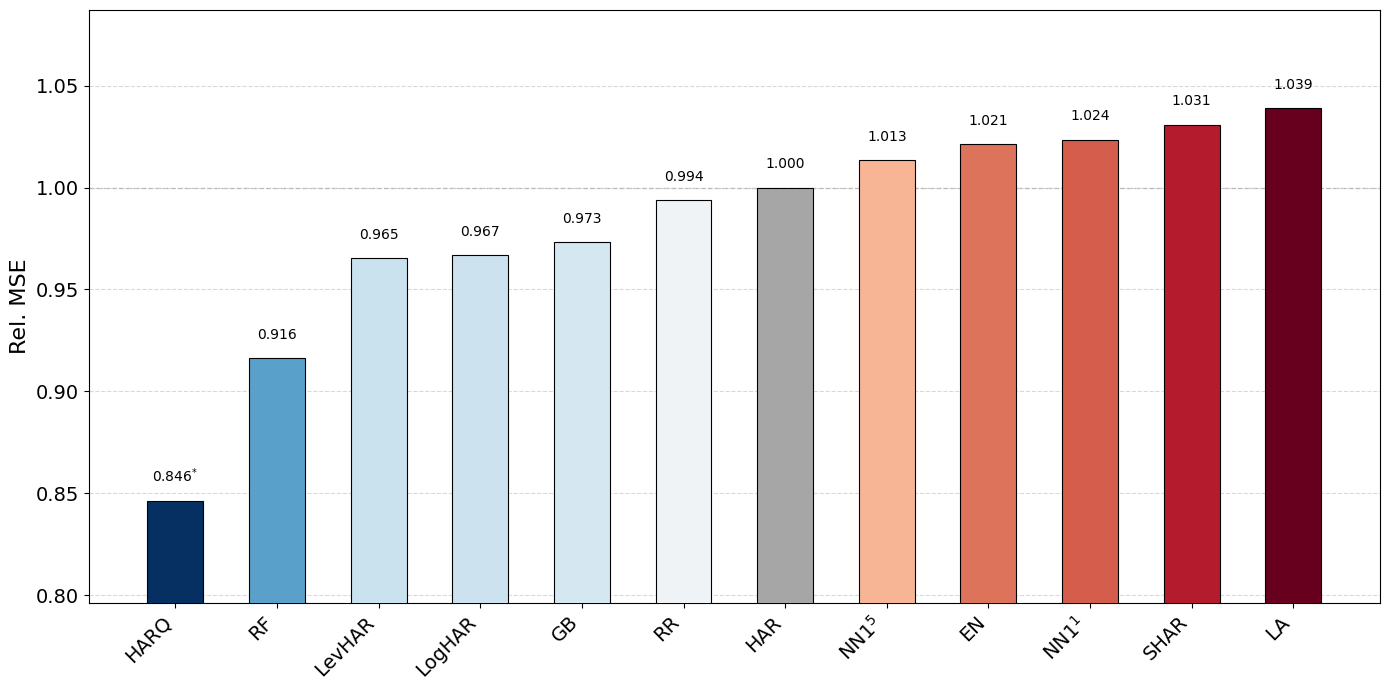

Figure saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results/relative_mse_MHAR.pdf


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ---------------- SAVE LOCATION ----------------
figure_dir = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results"
os.makedirs(figure_dir, exist_ok=True)

# ---------------- PREPARE DATA ----------------
plot_df = summary_table.copy()

# Ensure HAR is included as benchmark bar
plot_df.loc["HAR", "Relative_MSE"] = 1.0
plot_df.loc["HAR", "Significance"] = ""

# Sort by Relative MSE
plot_df = plot_df.sort_values("Relative_MSE").copy()

# Rename labels for plotting
label_map = {
    "HAR": "HAR",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": r"NN1$^{1}$",
    "NN1_ensemble": r"NN1$^{5}$"
}
plot_df["Display_Name"] = [label_map.get(idx, idx) for idx in plot_df.index]

values = plot_df["Relative_MSE"].values
x = np.arange(len(plot_df))

# ---------------- COLORS ----------------
norm = mcolors.TwoSlopeNorm(
    vmin=values.min(),
    vcenter=1.0,
    vmax=values.max()
)

cmap = cm.get_cmap("RdBu_r")   # blue = better, red = worse
colors = cmap(norm(values))

# Make HAR neutral grey
har_pos = plot_df.index.get_loc("HAR")
colors[har_pos] = (0.65, 0.65, 0.65, 1.0)

# ---------------- PLOT ----------------
fig, ax = plt.subplots(figsize=(14, 7))

ax.bar(
    x,
    values,
    width=0.55,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

# Light benchmark line at 1.0 behind bars
ax.axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    alpha=0.35,
    zorder=1
)

# ---------------- VALUE LABELS WITH SUPERSCRIPT STARS ----------------
y_range = values.max() - values.min()
value_offset = max(y_range * 0.03, 0.008)

for i, (_, row) in enumerate(plot_df.iterrows()):
    val = row["Relative_MSE"]
    stars = row["Significance"]

    if stars != "":
        label = rf"{val:.3f}$^{{{stars}}}$"
    else:
        label = f"{val:.3f}"

    ax.text(
        i,
        val + value_offset,
        label,
        fontsize=10,
        ha="center",
        va="bottom",
        color="black",
        zorder=4
    )

# ---------------- AXES ----------------
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Display_Name"], rotation=45, ha="right", fontsize=14)
ax.set_ylabel("Rel. MSE", fontsize=16)
plt.yticks(fontsize=14)

# Keep the tighter y-axis so differences in model performance remain visible
ymin = min(0.80, values.min() - 0.05)
ymax = values.max() + value_offset + 0.04
ax.set_ylim(ymin, ymax)

# Grid and background consistent with your other figures
ax.grid(True, linestyle="--", alpha=0.3, color="gray", axis="y")
ax.set_axisbelow(True)
ax.set_facecolor("white")

# Full border box
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color("black")

plt.tight_layout()

# ---------------- SAVE ----------------
save_path = os.path.join(figure_dir, "relative_mse_MHAR.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Figure saved to: {save_path}")

## Step 5: Performance Across Volatility Regimes

Following Christensen et al. (2023) Figure 5, we decompose forecast accuracy across 
the realized variance distribution by splitting the test set into terciles based on 
observed realized variance levels. This reveals whether model outperformance is 
concentrated in calm markets, normal conditions, or stress episodes. Given our test 
period spans both the low-volatility regime of 2017 and the COVID-19 spike of early 
2020, this decomposition is particularly informative.

In [16]:
# --- Define volatility terciles ---
rv_terciles = np.percentile(y_actual, [33.33, 66.67])
low_mask    = y_actual <= rv_terciles[0]
mid_mask    = (y_actual > rv_terciles[0]) & (y_actual <= rv_terciles[1])
high_mask   = y_actual > rv_terciles[1]

regime_labels = {
    "Low volatility":    low_mask,
    "Normal volatility": mid_mask,
    "High volatility":   high_mask
}

print(f"Volatility regime thresholds (annualized %):")
print(f"  Low:    RV <= {np.sqrt(rv_terciles[0]*252)*100:.2f}%  ({low_mask.sum()} obs)")
print(f"  Normal: RV in ({np.sqrt(rv_terciles[0]*252)*100:.2f}%, {np.sqrt(rv_terciles[1]*252)*100:.2f}%]  ({mid_mask.sum()} obs)")
print(f"  High:   RV >  {np.sqrt(rv_terciles[1]*252)*100:.2f}%  ({high_mask.sum()} obs)")
print()

# --- Compute relative MSE per regime ---
regime_results = {}
for regime, mask in regime_labels.items():
    mse_har_regime = np.mean((y_actual[mask] - forecasts["HAR"][mask])**2)
    regime_row = {}
    for name, forecast in forecasts.items():
        mse_i = np.mean((y_actual[mask] - forecast[mask])**2)
        regime_row[name] = mse_i / mse_har_regime
    regime_results[regime] = regime_row

regime_df = pd.DataFrame(regime_results).round(4)
regime_df = regime_df.reindex(summary_table.index)

print(f"Relative MSE by Volatility Regime (vs HAR)")
print(f"{'Model':<20} {'Low Vol':<15} {'Normal Vol':<15} {'High Vol':<15}")
print("-" * 65)
for model in regime_df.index:
    low  = regime_df.loc[model, "Low volatility"]
    mid  = regime_df.loc[model, "Normal volatility"]
    high = regime_df.loc[model, "High volatility"]
    print(f"{model:<20} {low:<15.4f} {mid:<15.4f} {high:<15.4f}")

Volatility regime thresholds (annualized %):
  Low:    RV <= 8.34%  (366 obs)
  Normal: RV in (8.34%, 12.18%]  (367 obs)
  High:   RV >  12.18%  (366 obs)

Relative MSE by Volatility Regime (vs HAR)
Model                Low Vol         Normal Vol      High Vol       
-----------------------------------------------------------------
HARQ                 0.5833          0.8597          0.8478         
RF                   0.5261          0.9118          0.9187         
LevHAR               0.7061          2.6454          0.9608         
LogHAR               0.2764          0.5219          0.9728         
GB                   3.3808          3.8924          0.9478         
RR                   1.0393          1.0524          0.9933         
HAR                  1.0000          1.0000          1.0000         
NN1_ensemble         2.9155          3.1933          0.9937         
EN                   4.9415          5.6231          0.9803         
NN1_best             3.0136          3.4366  

## Step 6: Visualise Regime Performance

We plot the relative MSE across volatility regimes for a selected subset of models,
providing a visual analogue to Figure 5 in Christensen et al. (2023).

Volatility regime thresholds (annualized %):
  Low:    RV <= 8.34%  (366 obs)
  Normal: RV in (8.34%, 12.18%]  (367 obs)
  High:   RV >  12.18%  (366 obs)

Relative MSE by Volatility Regime (vs HAR)
Model                Low Vol         Normal Vol      High Vol       
-----------------------------------------------------------------
HAR                  1.0000          1.0000          1.0000         
LogHAR               0.2764          0.5219          0.9728         
LevHAR               0.7061          2.6454          0.9608         
SHAR                 0.9983          0.9953          1.0311         
HARQ                 0.5833          0.8597          0.8478         
RR                   1.0393          1.0524          0.9933         
LA                   5.0551          5.7589          0.9971         
EN                   4.9415          5.6231          0.9803         
RF                   0.5261          0.9118          0.9187         
GB                   3.3808          3.8924  

/var/folders/ym/wl40dz313jq5xxzrl0tc87w00000gn/T/ipykernel_26240/41097685.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")
/var/folders/ym/wl40dz313jq5xxzrl0tc87w00000gn/T/ipykernel_26240/41097685.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu_r")
/var/folders/ym/wl40dz313jq5xxzrl0tc87w00000gn/T/ipykernel_26240/41097685.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdBu

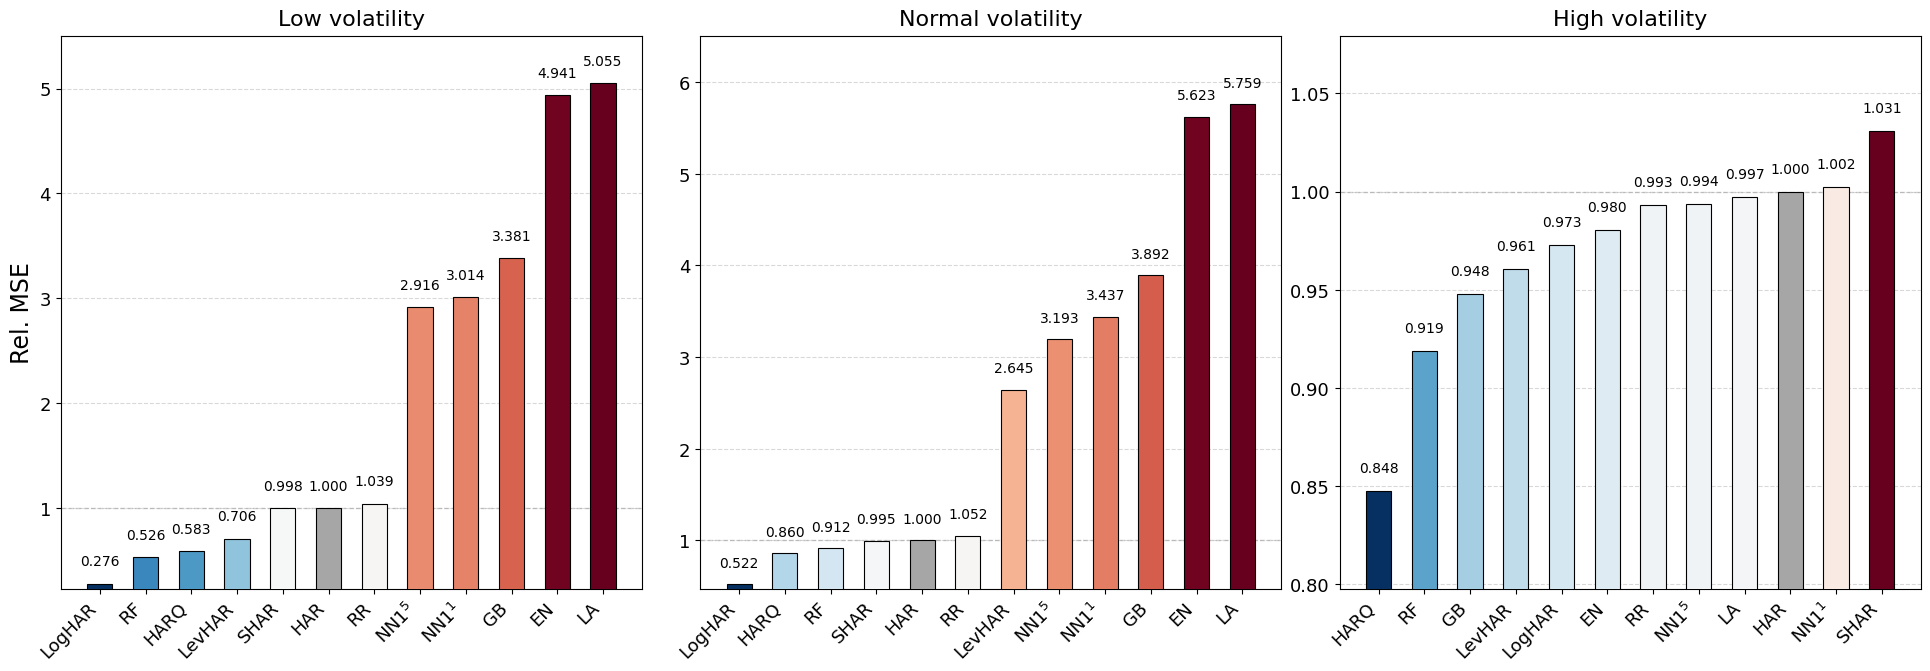

Figure saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results/relative_mse_MHAR_volatility_regimes.pdf


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ============================================================
# SAVE LOCATION
# ============================================================
figure_dir = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Figures/Results"
os.makedirs(figure_dir, exist_ok=True)

# ============================================================
# DEFINE VOLATILITY TERCILES
# ============================================================
rv_terciles = np.percentile(y_actual, [33.33, 66.67])

low_mask  = y_actual <= rv_terciles[0]
mid_mask  = (y_actual > rv_terciles[0]) & (y_actual <= rv_terciles[1])
high_mask = y_actual > rv_terciles[1]

regime_labels = {
    "Low volatility": low_mask,
    "Normal volatility": mid_mask,
    "High volatility": high_mask
}

print("Volatility regime thresholds (annualized %):")
print(f"  Low:    RV <= {np.sqrt(rv_terciles[0] * 252) * 100:.2f}%  ({low_mask.sum()} obs)")
print(f"  Normal: RV in ({np.sqrt(rv_terciles[0] * 252) * 100:.2f}%, {np.sqrt(rv_terciles[1] * 252) * 100:.2f}%]  ({mid_mask.sum()} obs)")
print(f"  High:   RV >  {np.sqrt(rv_terciles[1] * 252) * 100:.2f}%  ({high_mask.sum()} obs)")
print()

# ============================================================
# COMPUTE RELATIVE MSE PER REGIME
# ============================================================
regime_results = {}

for regime, mask in regime_labels.items():
    mse_har_regime = np.mean((y_actual[mask] - forecasts["HAR"][mask]) ** 2)

    regime_row = {}
    for name, forecast in forecasts.items():
        mse_i = np.mean((y_actual[mask] - forecast[mask]) ** 2)
        regime_row[name] = mse_i / mse_har_regime

    regime_results[regime] = regime_row

regime_df = pd.DataFrame(regime_results).round(4)

# Ensure HAR is included and exactly 1.00
regime_df.loc["HAR", :] = 1.0

print("Relative MSE by Volatility Regime (vs HAR)")
print(f"{'Model':<20} {'Low Vol':<15} {'Normal Vol':<15} {'High Vol':<15}")
print("-" * 65)
for model in regime_df.index:
    low  = regime_df.loc[model, "Low volatility"]
    mid  = regime_df.loc[model, "Normal volatility"]
    high = regime_df.loc[model, "High volatility"]
    print(f"{model:<20} {low:<15.4f} {mid:<15.4f} {high:<15.4f}")

# ============================================================
# LABEL MAP
# ============================================================
label_map = {
    "HAR": "HAR",
    "LogHAR": "LogHAR",
    "LevHAR": "LevHAR",
    "SHAR": "SHAR",
    "HARQ": "HARQ",
    "RR": "RR",
    "LA": "LA",
    "EN": "EN",
    "RF": "RF",
    "GB": "GB",
    "NN1_best": r"NN1$^{1}$",
    "NN1_ensemble": r"NN1$^{5}$"
}

# ============================================================
# CREATE 3-PANEL FIGURE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 8.5), sharey=False)

regime_order = ["Low volatility", "Normal volatility", "High volatility"]

for ax, regime in zip(axes, regime_order):
    panel_df = regime_df[[regime]].copy()
    panel_df = panel_df.sort_values(by=regime)

    values = panel_df[regime].values
    model_order = panel_df.index.tolist()
    display_names = [label_map.get(idx, idx) for idx in model_order]
    x = np.arange(len(panel_df))

    # Color mapping centered at HAR = 1.0
    norm = mcolors.TwoSlopeNorm(
        vmin=values.min(),
        vcenter=1.0,
        vmax=values.max()
    )
    cmap = cm.get_cmap("RdBu_r")
    colors = cmap(norm(values))

    # Make HAR grey
    har_pos = model_order.index("HAR")
    colors[har_pos] = (0.65, 0.65, 0.65, 1.0)

    # Bars
    ax.bar(
        x,
        values,
        width=0.55,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
        zorder=3
    )

    # Benchmark line
    ax.axhline(
        1.0,
        color="gray",
        linestyle="--",
        linewidth=1.0,
        alpha=0.35,
        zorder=1
    )

    # Value labels
    y_range = values.max() - values.min()
    value_offset = max(y_range * 0.03, 0.008)

    for i, val in enumerate(values):
        ax.text(
            i,
            val + value_offset,
            f"{val:.3f}",
            fontsize=10,
            ha="center",
            va="bottom",
            color="black",
            zorder=4
        )

    # Axes formatting
    ax.set_xticks(x)
    ax.set_xticklabels(display_names, rotation=45, ha="right", fontsize=13)
    ax.set_title(regime, fontsize=16, pad=8)
    ax.tick_params(axis="y", labelsize=13)

    # Panel-specific y-axis control
    ymin = min(0.80, values.min() - 0.05)

    if regime == "Low volatility":
        ymax = 5.5
    elif regime == "Normal volatility":
        ymax = 6.5
    else:
        ymax = values.max() + value_offset + 0.04

    ax.set_ylim(ymin, ymax)

    ax.grid(True, linestyle="--", alpha=0.3, color="gray", axis="y")
    ax.set_axisbelow(True)
    ax.set_facecolor("white")

    # Full border box
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("black")

# Shared y-label
axes[0].set_ylabel("Rel. MSE", fontsize=17)

# Improve spacing between panels and bottom labels
fig.subplots_adjust(wspace=0.10, bottom=0.23)

# ============================================================
# SAVE
# ============================================================
save_path = os.path.join(figure_dir, "relative_mse_MHAR_volatility_regimes.pdf")
plt.savefig(save_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Figure saved to: {save_path}")

## Step 7: Pairwise Relative MSE Table with Diebold-Mariano Tests

Following Christensen et al. (2023) Tables 2-3, we construct a full pairwise relative MSE matrix. Each entry (i,j) reports the MSE of the row model i relative to the column model j. A value below unity indicates that the column model j outperforms the row model 
i. Diebold-Mariano tests are conducted for each pair, testing the one-sided alternative that the column model outperforms the row model. Significance stars are appended to each entry, with * p<0.10, ** p<0.05, and *** p<0.01. This structure directly mirrors Table 2 
in Christensen et al. (2023), adapted to the single-index setting of the EURO STOXX 50.b

In [22]:
from scipy import stats

def dm_test_pairwise(actual, forecast_i, forecast_j, lags=5):
    """
    Pairwise DM test.
    H0: Equal predictive accuracy between model i and model j.
    H1: Model j outperforms model i (one-sided).
    Loss differential d_t = e_i^2 - e_j^2.
    Positive DM stat means model j beats model i.
    Returns DM statistic and one-sided p-value.
    """
    e_i = actual - forecast_i
    e_j = actual - forecast_j
    
    # Loss differential: positive means j is better than i
    d = e_i**2 - e_j**2
    
    T = len(d)
    d_mean = d.mean()
    
    # Newey-West variance estimate
    d_demeaned = d - d_mean
    gamma_0 = np.mean(d_demeaned**2)
    nw_var = gamma_0
    for lag in range(1, lags + 1):
        gamma_lag = np.mean(d_demeaned[lag:] * d_demeaned[:-lag])
        nw_var += 2 * (1 - lag / (lags + 1)) * gamma_lag
    
    # Guard against numerical issues
    if nw_var <= 0:
        return np.nan, np.nan
    
    dm_stat = d_mean / np.sqrt(nw_var / T)
    
    # One-sided p-value: H1 that j beats i (positive DM stat)
    p_value = 1 - stats.norm.cdf(dm_stat)
    
    return dm_stat, p_value

def significance_stars(p_value):
    if np.isnan(p_value):
        return ""
    if p_value < 0.01:
        return "***"
    elif p_value < 0.05:
        return "**"
    elif p_value < 0.10:
        return "*"
    return ""

# --- Define model order following the paper ---
model_order = [
    "HAR", "LogHAR", "LevHAR", "SHAR", "HARQ",
    "RR", "LA", "EN",
    "RF", "GB",
    "NN1_best", "NN1_ensemble"
]

n_models = len(model_order)

# --- Compute pairwise relative MSE and DM tests ---
# Entry (i,j): MSE_i / MSE_j with DM test H1: j beats i
rel_mse_matrix  = pd.DataFrame(index=model_order, columns=model_order, dtype=float)
pval_matrix     = pd.DataFrame(index=model_order, columns=model_order, dtype=float)
dm_stat_matrix  = pd.DataFrame(index=model_order, columns=model_order, dtype=float)

for i, model_i in enumerate(model_order):
    for j, model_j in enumerate(model_order):
        if model_i == model_j:
            rel_mse_matrix.loc[model_i, model_j] = 1.0
            pval_matrix.loc[model_i, model_j]    = np.nan
            dm_stat_matrix.loc[model_i, model_j] = np.nan
        else:
            mse_i = np.mean((y_actual - forecasts[model_i])**2)
            mse_j = np.mean((y_actual - forecasts[model_j])**2)
            rel_mse_matrix.loc[model_i, model_j] = mse_i / mse_j
            
            dm_stat, p_val = dm_test_pairwise(
                actual=y_actual,
                forecast_i=forecasts[model_i],
                forecast_j=forecasts[model_j],
                lags=5
            )
            pval_matrix.loc[model_i, model_j]    = p_val
            dm_stat_matrix.loc[model_i, model_j] = dm_stat

# --- Build display matrix with stars appended ---
display_matrix = pd.DataFrame(index=model_order, columns=model_order, dtype=object)

for model_i in model_order:
    for model_j in model_order:
        if model_i == model_j:
            display_matrix.loc[model_i, model_j] = "—"
        else:
            rel_mse = rel_mse_matrix.loc[model_i, model_j]
            p_val   = pval_matrix.loc[model_i, model_j]
            stars   = significance_stars(p_val)
            display_matrix.loc[model_i, model_j] = f"{rel_mse:.4f}{stars}"

print("Pairwise Relative MSE Matrix — MHAR Feature Set")
print("Entry (i,j): MSE_i / MSE_j | Stars: H1 that column model j beats row model i")
print("Significance: * p<0.10, ** p<0.05, *** p<0.01")
print()
display(display_matrix)

Pairwise Relative MSE Matrix — MHAR Feature Set
Entry (i,j): MSE_i / MSE_j | Stars: H1 that column model j beats row model i
Significance: * p<0.10, ** p<0.05, *** p<0.01



,HAR,LogHAR,LevHAR,SHAR,HARQ,RR,LA,EN,RF,GB,NN1_best,NN1_ensemble
HAR,—,1.0342,1.0360,0.9701,1.1818*,1.0062,0.9624,0.9792,1.0914,1.0274,0.9770,0.9868
LogHAR,0.9669,—,1.0018,0.9381,1.1427,0.9729,0.9305,0.9468,1.0554,0.9935,0.9447,0.9542
LevHAR,0.9652,0.9982,—,0.9364,1.1407*,0.9712,0.9289,0.9451,1.0535,0.9917,0.9430,0.9525
SHAR,1.0308,1.0660,1.0679,—,1.2182*,1.0372,0.9920,1.0093,1.1250,1.0591,1.0071,1.0172
HARQ,0.8462,0.8751,0.8767,0.8209,—,0.8514,0.8143,0.8286,0.9236,0.8694,0.8267,0.8350
RR,0.9938,1.0278,1.0296,0.9641,1.1745*,—,0.9564,0.9731,1.0847,1.0211,0.9710,0.9808
LA,1.0391**,1.0746*,1.0765*,1.0081,1.2280**,1.0456***,—,1.0175*,1.1341*,1.0676*,1.0152,1.0254
EN,1.0213,1.0562,1.0581*,0.9908,1.2069**,1.0276***,0.9828,—,1.1147*,1.0493,0.9978,1.0078
RF,0.9162,0.9475,0.9492,0.8889,1.0828*,0.9219,0.8817,0.8971,—,0.9414,0.8951,0.9042
GB,0.9733,1.0066,1.0083,0.9442,1.1502**,0.9793,0.9367,0.9530,1.0623**,—,0.9509,0.9605


## Step 7b: Export Pairwise Table to LaTeX

We export the pairwise relative MSE table to LaTeX format for direct inclusion in the 
thesis, following the structure of Table 2 in Christensen et al. (2023).

In [25]:
# --- Export to LaTeX ---
latex_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR"
os.makedirs(latex_path, exist_ok=True)

# Shorten column names for LaTeX table width
short_names = {
    "HAR":          "HAR",
    "LogHAR":       "LogHAR",
    "LevHAR":       "LevHAR",
    "SHAR":         "SHAR",
    "HARQ":         "HARQ",
    "RR":           "RR",
    "LA":           "LA",
    "EN":           "EN",
    "RF":           "RF",
    "GB":           "GB",
    "NN1_best":     "NN1$^1$",
    "NN1_ensemble": "NN1$^5$"
}

display_latex = display_matrix.copy()
display_latex.index   = [short_names[m] for m in model_order]
display_latex.columns = [short_names[m] for m in model_order]

latex_str = display_latex.to_latex(
    escape=False,
    caption="Pairwise relative MSE and Diebold-Mariano tests — MHAR feature set. "
            "Each entry $(i,j)$ reports the MSE of row model $i$ relative to column "
            "model $j$. Significance stars indicate rejection of equal predictive "
            "accuracy in favour of the column model: * $p<0.10$, ** $p<0.05$, "
            "*** $p<0.01$. Newey-West standard errors with 5 lags.",
    label="tab:pairwise_mse_mhar",
    position="htbp"
)

with open(os.path.join(latex_path, "pairwise_mse_mhar.tex"), "w") as f:
    f.write(latex_str)

print(f"LaTeX table saved to: {latex_path}/pairwise_mse_mhar.tex")

LaTeX table saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/pairwise_mse_mhar.tex
